##*SETUP & DATA PREPARATION*

In [5]:
!pip install -q kagglehub
import kagglehub
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Add, Activation, BatchNormalization, DepthwiseConv2D, concatenate, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, InceptionV3, DenseNet121
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import os
# 1. Hardware and Reproducibility Setup
tf.random.set_seed(42)
np.random.seed(42)
# 2. Global Parameters
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
NUM_CLASSES = 4 # We are tracking 4 specific emotions, ignoring the garbage folder
# 3. Download the Kaggle Emotion Dataset directly into Colab
print("Downloading dataset directly from Kaggle...")
base_path = kagglehub.dataset_download("anshtanwar/pets-facial-expression-dataset")
# Handle potential nested folder structures
subdirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
dataset_path = subdirs[0] if len(subdirs) == 1 else base_path
print(f"Dataset is ready at: {dataset_path}")
# 4. Data Augmentation
# Applies random rotations, shifts, and flips to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.2,
    height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
    horizontal_flip=True, validation_split=0.2
)
#Explicitly define only the valid expression folders to ignore "Master Folder"
valid_classes = ['Angry', 'happy', 'Sad', 'Other']
print("\nLoading Training Data:")
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    classes=valid_classes, # Filter out garbage folders
    class_mode='categorical',
    subset='training'
)
print("\nLoading Validation Data:")
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    classes=valid_classes, # Filter out garbage folders
    class_mode='categorical',
    subset='validation',
    shuffle=False # Must be false to align metrics correctly
)

Using Colab cache for faster access to the 'pets-facial-expression-dataset' dataset.
Dataset is ready at: /kaggle/input/pets-facial-expression-dataset

Loading Training Data:
Found 800 images belonging to 4 classes.

Loading Validation Data:
Found 200 images belonging to 4 classes.


##*NETWORK ARCHITECTURES FROM SCRATCH*

In [6]:
# --- 1. Visual Geometry Group (VGG16) ---
def build_vgg():
    """
    Builds VGG16 from scratch.
    Architecture: 5 convolutional blocks with increasing filters [64, 128, 256, 512, 512],
    each followed by MaxPooling, then 3 fully-connected layers.
    """
    inputs = Input(shape=(224, 224, 3))
    # Block 1: 64 filters
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    # Block 2: 128 filters
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    # Block 3: 256 filters
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    # Block 4: 512 filters
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    # Block 5: 512 filters
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    # Fully Connected Classifier
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name="VGG16_Scratch")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model
# --- 2. Residual Neural Network (ResNet) ---
def residual_block(x, filters, stride=1):
    """
    Creates a residual block with a skip connection.
    If dimensions change (stride > 1 or filter mismatch), the shortcut is
    projected using a 1x1 convolution to match dimensions before addition.
    """
    shortcut = x
    # Main path: two 3x3 convolutions with BatchNorm
    x = Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    # Projection shortcut to match dimensions if needed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    x = Add()([x, shortcut])
    return Activation('relu')(x)
def build_resnet():
    """
    Builds a ResNet-18 style architecture from scratch.
    Stages: initial stem → 4 stages with increasing filters [64, 128, 256, 512]
    each containing 2 residual blocks, then Global Average Pooling + classifier.
    """
    inputs = Input(shape=(224, 224, 3))
    # Stem: initial large convolution to quickly reduce spatial dimensions
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(3, strides=2, padding='same')(x)
    # Stage 1: 64 filters, no downsampling
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    # Stage 2: 128 filters, downsample with stride=2
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)
    # Stage 3: 256 filters, downsample with stride=2
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)
    # Stage 4: 512 filters, downsample with stride=2
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512)
    # Classifier head
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name="ResNet_Scratch")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model
# --- 3. MobileNet ---
def depthwise_sep_block(x, filters, stride=1):
    """
    A single Depthwise Separable block:
    - DepthwiseConv2D: filters each channel independently (spatial features).
    - 1x1 Conv2D: combines channels (feature generation).
    - BatchNorm + ReLU after each step for stable training.
    """
    x = DepthwiseConv2D((3, 3), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, (1, 1), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x
def build_mobilenet():
    """
    Builds MobileNet V1 from scratch using 13 depthwise separable layers.
    Filter progression: 32 → 64 → 128 → 256 → 512 → 1024,
    with stride-2 layers at key points to reduce spatial dimensions.
    """
    inputs = Input(shape=(224, 224, 3))
    # Initial standard convolution
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    # 13 Depthwise Separable blocks (MobileNet V1 architecture)
    x = depthwise_sep_block(x, 64)
    x = depthwise_sep_block(x, 128, stride=2)
    x = depthwise_sep_block(x, 128)
    x = depthwise_sep_block(x, 256, stride=2)
    x = depthwise_sep_block(x, 256)
    x = depthwise_sep_block(x, 512, stride=2)
    x = depthwise_sep_block(x, 512)
    x = depthwise_sep_block(x, 512)
    x = depthwise_sep_block(x, 512)
    x = depthwise_sep_block(x, 512)
    x = depthwise_sep_block(x, 512)
    x = depthwise_sep_block(x, 1024, stride=2)
    x = depthwise_sep_block(x, 1024)
    # Classifier head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.25)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name="MobileNet_Scratch")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model
# --- 4. Inception V3 ---
def inception_module(x, f_1x1, f_3x3_reduce, f_3x3, f_5x5_reduce, f_5x5, f_pool):
    """
    Full Inception module with 4 parallel branches:
    - Branch 1: 1x1 convolution (cheap, captures fine features)
    - Branch 2: 1x1 bottleneck → 3x3 convolution
    - Branch 3: 1x1 bottleneck → 5x5 convolution (factorized for efficiency)
    - Branch 4: 3x3 MaxPool → 1x1 projection
    All branches concatenated along the channel axis.
    """
    # Branch 1: 1x1 conv
    b1 = Conv2D(f_1x1, (1, 1), padding='same', activation='relu')(x)
    # Branch 2: 1x1 bottleneck → 3x3
    b2 = Conv2D(f_3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    b2 = Conv2D(f_3x3, (3, 3), padding='same', activation='relu')(b2)
    # Branch 3: 1x1 bottleneck → 5x5 (factorized as two 3x3 for efficiency)
    b3 = Conv2D(f_5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    b3 = Conv2D(f_5x5, (3, 3), padding='same', activation='relu')(b3)
    b3 = Conv2D(f_5x5, (3, 3), padding='same', activation='relu')(b3)
    # Branch 4: MaxPool → 1x1 projection
    b4 = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    b4 = Conv2D(f_pool, (1, 1), padding='same', activation='relu')(b4)
    return concatenate([b1, b2, b3, b4])
def build_inception():
    """
    Builds an Inception V3-style network from scratch.
    Uses a stem of standard convolutions followed by stacked Inception modules
    with increasing filter complexity, then Global Average Pooling + classifier.
    """
    inputs = Input(shape=(224, 224, 3))
    # Stem
    x = Conv2D(32, (3, 3), strides=(2, 2), padding='same', activation='relu')(inputs)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Conv2D(80, (1, 1), padding='same', activation='relu')(x)
    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    # Inception modules with increasing complexity
    # (f_1x1, f_3x3_reduce, f_3x3, f_5x5_reduce, f_5x5, f_pool)
    x = inception_module(x, 64,  96,  128, 16, 32,  32)
    x = inception_module(x, 128, 128, 192, 32, 96,  64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = inception_module(x, 192, 96,  208, 16, 48,  64)
    x = inception_module(x, 160, 112, 224, 24, 64,  64)
    x = inception_module(x, 128, 128, 256, 24, 64,  64)
    x = inception_module(x, 112, 144, 288, 32, 64,  64)
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = inception_module(x, 384, 192, 384, 48, 128, 128)
    # Classifier head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name="InceptionV3_Scratch")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model
# --- 5. DenseNet121 ---
def dense_block(x, num_layers, growth_rate):
    """
    A Dense Block: each layer receives feature maps from ALL preceding layers.
    growth_rate (k): number of feature maps each layer contributes.
    Uses Bottleneck design: BN → ReLU → 1x1 Conv → BN → ReLU → 3x3 Conv.
    """
    for _ in range(num_layers):
        # Bottleneck: reduce channels before 3x3 conv
        cb = BatchNormalization()(x)
        cb = Activation('relu')(cb)
        cb = Conv2D(4 * growth_rate, (1, 1), padding='same')(cb)  # 1x1 bottleneck
        cb = BatchNormalization()(cb)
        cb = Activation('relu')(cb)
        cb = Conv2D(growth_rate, (3, 3), padding='same')(cb)       # 3x3 conv
        x = concatenate([x, cb])  # Dense connection: concatenate all prior outputs
    return x
def transition_block(x, compression=0.5):
    """
    Transition Layer between Dense Blocks.
    Reduces the number of feature maps by 'compression' factor (theta),
    then halves spatial dimensions with average pooling.
    """
    num_filters = int(x.shape[-1] * compression)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(num_filters, (1, 1), padding='same')(x)
    x = tf.keras.layers.AveragePooling2D((2, 2), strides=(2, 2))(x)
    return x
def build_densenet():
    """
    Builds DenseNet-121 from scratch.
    Architecture: Stem → 4 Dense Blocks [6, 12, 24, 16 layers] separated by
    Transition Layers → Global Average Pooling → Classifier.
    Growth rate k=32 as in the original paper.
    """
    growth_rate = 32
    inputs = Input(shape=(224, 224, 3))
    # Stem
    x = Conv2D(64, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    # Dense Block 1: 6 layers → Transition
    x = dense_block(x, num_layers=6, growth_rate=growth_rate)
    x = transition_block(x)
    # Dense Block 2: 12 layers → Transition
    x = dense_block(x, num_layers=12, growth_rate=growth_rate)
    x = transition_block(x)
    # Dense Block 3: 24 layers → Transition
    x = dense_block(x, num_layers=24, growth_rate=growth_rate)
    x = transition_block(x)
    # Dense Block 4: 16 layers (final, no transition)
    x = dense_block(x, num_layers=16, growth_rate=growth_rate)
    # Classifier head
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inputs, outputs, name="DenseNet121_Scratch")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## *TRAINING & EVALUATION LOOP*


Training and Evaluating: VGG
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.2450 - loss: 1.5762 - val_accuracy: 0.2500 - val_loss: 1.3866
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 747ms/step - accuracy: 0.2450 - loss: 1.3889 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 747ms/step - accuracy: 0.2450 - loss: 1.3875 - val_accuracy: 0.2500 - val_loss: 1.3869
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 750ms/step - accuracy: 0.2475 - loss: 1.3878 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 716ms/step - accuracy: 0.2412 - loss: 1.3872 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 756ms/step - accuracy: 0.2288 - loss: 1.3879 - val_accuracy: 0.2500 - val_loss: 1.3865
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 714ms/step - accuracy: 0.2500 - loss: 1.3872 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 757ms/step - accuracy: 0.222

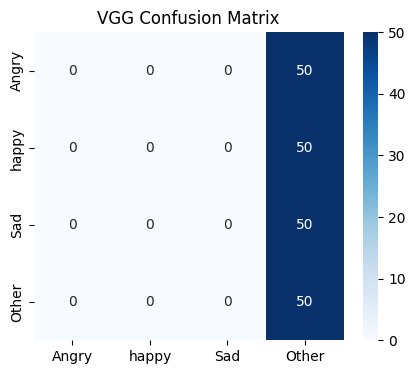


Training and Evaluating: ResNet
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 925ms/step - accuracy: 0.2587 - loss: 2.4463 - val_accuracy: 0.2500 - val_loss: 2169.2351
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 553ms/step - accuracy: 0.2725 - loss: 1.5057 - val_accuracy: 0.2500 - val_loss: 31.0160
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 552ms/step - accuracy: 0.3113 - loss: 1.3980 - val_accuracy: 0.2400 - val_loss: 1.7017
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 553ms/step - accuracy: 0.3200 - loss: 1.3809 - val_accuracy: 0.2650 - val_loss: 1.6061
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 560ms/step - accuracy: 0.3313 - loss: 1.3658 - val_accuracy: 0.2500 - val_loss: 1.6062
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 569ms/step - accuracy: 0.3350 - loss: 1.3721 - val_accuracy: 0.3100 - val_loss: 2.8600
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 657ms/step - accuracy: 0.3713 - loss: 1.3424 - val_accuracy: 0.2600 - val_loss: 5.4261
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 563ms/step - accur

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 563ms/step

Classification Report for ResNet:
              precision    recall  f1-score   support

       Angry       0.31      0.78      0.44        50
       happy       0.41      0.18      0.25        50
         Sad       0.41      0.30      0.34        50
       Other       0.21      0.06      0.09        50

    accuracy                           0.33       200
   macro avg       0.33      0.33      0.28       200
weighted avg       0.33      0.33      0.28       200



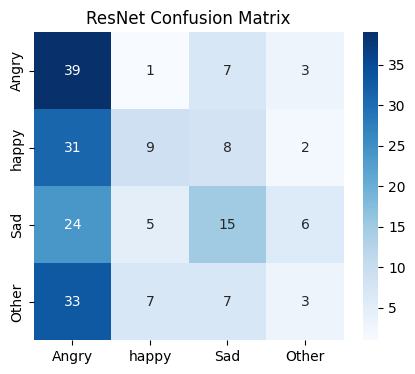


Training and Evaluating: MobileNet
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2562 - loss: 1.6038 - val_accuracy: 0.2500 - val_loss: 1.3884
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 557ms/step - accuracy: 0.2637 - loss: 1.4584 - val_accuracy: 0.2500 - val_loss: 1.4031
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 555ms/step - accuracy: 0.2875 - loss: 1.4451 - val_accuracy: 0.2500 - val_loss: 1.4245
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 560ms/step - accuracy: 0.3038 - loss: 1.4511 - val_accuracy: 0.2500 - val_loss: 1.5016
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 584ms/step - accuracy: 0.3363 - loss: 1.4010 - val_accuracy: 0.2500 - val_loss: 1.5548
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 562ms/step - accuracy: 0.3100 - loss: 1.4647 - val_accuracy: 0.2500 - val_loss: 1.6764
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 558ms/step - accuracy: 0.3212 - loss: 1.4176 - val_accuracy: 0.2500 - val_loss: 1.7592
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 557ms/step - accuracy:

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 781ms/step

Classification Report for MobileNet:
              precision    recall  f1-score   support

       Angry       0.00      0.00      0.00        50
       happy       0.00      0.00      0.00        50
         Sad       0.00      0.00      0.00        50
       Other       0.25      1.00      0.40        50

    accuracy                           0.25       200
   macro avg       0.06      0.25      0.10       200
weighted avg       0.06      0.25      0.10       200



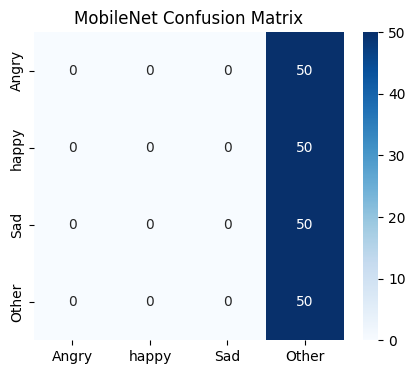


Training and Evaluating: Inception
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.2412 - loss: 1.3888 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 684ms/step - accuracy: 0.2288 - loss: 1.3870 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 563ms/step - accuracy: 0.2375 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 570ms/step - accuracy: 0.2475 - loss: 1.3865 - val_accuracy: 0.2500 - val_loss: 1.3864
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 568ms/step - accuracy: 0.2288 - loss: 1.3867 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 565ms/step - accuracy: 0.2325 - loss: 1.3870 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 555ms/step - accuracy: 0.2387 - loss: 1.3868 - val_accuracy: 0.2500 - val_loss: 1.3863
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 556ms/step - accuracy:

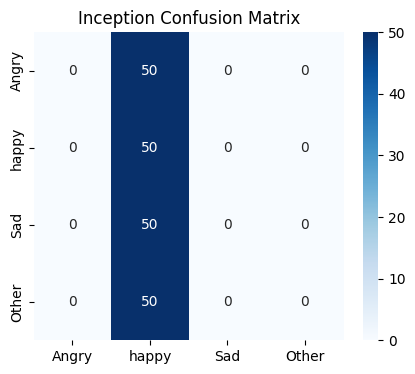


Training and Evaluating: DenseNet
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.2537 - loss: 1.6185 - val_accuracy: 0.2650 - val_loss: 2.2528
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 642ms/step - accuracy: 0.3013 - loss: 1.3919 - val_accuracy: 0.2800 - val_loss: 1.4681
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 648ms/step - accuracy: 0.3325 - loss: 1.3729 - val_accuracy: 0.2650 - val_loss: 1.4054
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 628ms/step - accuracy: 0.3250 - loss: 1.3641 - val_accuracy: 0.2550 - val_loss: 1.4167
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy: 0.3587 - loss: 1.3471 - val_accuracy: 0.2550 - val_loss: 1.4307
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 673ms/step - accuracy: 0.3212 - loss: 1.3598 - val_accuracy: 0.2550 - val_loss: 1.4331
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 631ms/step - accuracy: 0.3500 - loss: 1.3521 - val_accuracy: 0.2800 - val_loss: 1.9021
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - accuracy:

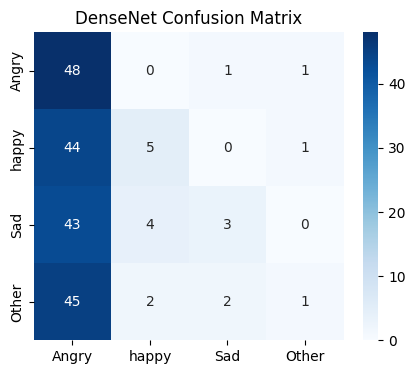


 BEST SCRATCH MODEL: ResNet (Accuracy: 0.3300)


In [7]:
import warnings
warnings.filterwarnings('ignore') # Suppress sklearn zero-division warnings for clean outputs
model_registry = {
    'VGG': build_vgg,
    'ResNet': build_resnet,
    'MobileNet': build_mobilenet,
    'Inception': build_inception,
    'DenseNet': build_densenet
}
EPOCHS_SCRATCH = 15 # Adjust if training is taking too long
model_performances = {}
# Loop through all 5 models to train, evaluate, and print the required assignment metrics
for model_name, builder_func in model_registry.items():
    print(f"\n{'='*40}\nTraining and Evaluating: {model_name}\n{'='*40}")
    model = builder_func()
    model.fit(train_generator, epochs=EPOCHS_SCRATCH, validation_data=validation_generator, verbose=1)
    # Reset generator to ensure predictions align with true labels perfectly
    validation_generator.reset()
    y_pred = np.argmax(model.predict(validation_generator), axis=1)
    y_true = validation_generator.classes
    class_labels = list(validation_generator.class_indices.keys())
    # Store the accuracy to determine the winner later
    model_performances[model_name] = accuracy_score(y_true, y_pred)
    # Print PDF Required Output: Precision, Recall, F1-Score
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
    # Print PDF Required Output: Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()
# Automatically determine the best performing model for Transfer Learning
best_model_name = max(model_performances, key=model_performances.get)
print(f"\n BEST SCRATCH MODEL: {best_model_name} (Accuracy: {model_performances[best_model_name]:.4f})")

##  *PRINT ACCURACY SUMMARY TABLE*

In [8]:
print("\n" + "="*45)
print("       MODEL ACCURACY SUMMARY (Scratch)")
print("="*45)
print(f"{'Model':<15} {'Accuracy':>10}")
print("-"*45)
for name, acc in sorted(model_performances.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<15} {acc*100:>9.2f}%")
print("="*45)
print(f"\n Best Model → {best_model_name} ({model_performances[best_model_name]*100:.2f}%)")


       MODEL ACCURACY SUMMARY (Scratch)
Model             Accuracy
---------------------------------------------
ResNet              33.00%
DenseNet            28.50%
VGG                 25.00%
MobileNet           25.00%
Inception           25.00%

 Best Model → ResNet (33.00%)


##*TRANSFER LEARNING ON BEST MODEL*

Applying ImageNet Transfer Learning to the winner: ResNet
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 865ms/step - accuracy: 0.2250 - loss: 1.6477 - val_accuracy: 0.2500 - val_loss: 1.3975
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 558ms/step - accuracy: 0.2500 - loss: 1.4316 - val_accuracy: 0.2500 - val_loss: 1.3942
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 556ms/step - accuracy: 0.2837 - loss: 1.3891 - val_accuracy: 0.2500 - val_loss: 1.3829
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 556ms/step - accuracy: 0.2675 - loss: 1.3938 - val_accuracy: 0.3800 - val_loss: 1.3819
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 553ms/step - accuracy: 0.2475 - loss: 1.3875 - val_accuracy: 0.3250 - val_loss: 1.3816
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 567ms/step - accuracy: 0.2825 - loss: 1.3774 - val_accuracy: 0.3350 - val_loss: 1.3795
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 557ms/step - accuracy: 0.2412 - loss: 1.3912 - val_accuracy: 0.3150 - val_l

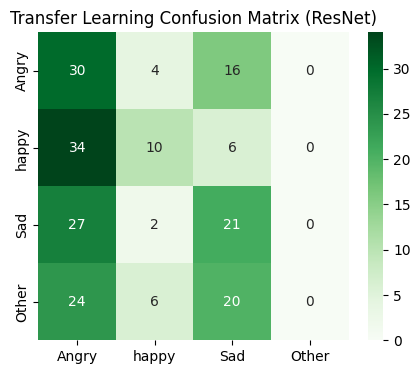

In [9]:
keras_app_mapping = {
    'VGG': VGG16,
    'ResNet': ResNet50,
    'MobileNet': MobileNetV2,
    'Inception': InceptionV3,
    'DenseNet': DenseNet121
}
print(f"Applying ImageNet Transfer Learning to the winner: {best_model_name}")
# Fetch the built-in Keras application corresponding to our winning scratch model
AppClass = keras_app_mapping[best_model_name]
# Load the model with pre-trained ImageNet weights, discarding the original 1000-class output
base_model = AppClass(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
# Freeze the convolutional base to prevent destroying the pre-trained features
for layer in base_model.layers:
    layer.trainable = False
# Attach custom classification layers for our specific 4-class emotion problem
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = Model(inputs=base_model.input, outputs=outputs)
tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the Transfer Learning model
tl_model.fit(train_generator, epochs=10, validation_data=validation_generator, verbose=1)
# Final Evaluation
validation_generator.reset()
y_pred_tl = np.argmax(tl_model.predict(validation_generator), axis=1)
y_true_tl = validation_generator.classes
print(f"\n--- FINAL TRANSFER LEARNING REPORT ({best_model_name}) ---")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_labels))
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_true_tl, y_pred_tl), annot=True, fmt='d', cmap='Greens', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Transfer Learning Confusion Matrix ({best_model_name})')
plt.show()